# NB01: Plant-Associated Genome Census

Classify genomes/species by plant compartment; establish sample sizes for downstream hypotheses.

**Steps:**
1. Parse `gtdb_metadata.ncbi_isolation_source` with regex for plant compartments
2. Cross-validate with `ncbi_env` EAV table (harmonized isolation_source, env_broad_scale, host)
3. Cross-validate with `kescience_bacdive.isolation` cat1/cat2/cat3 via GCA accession bridge
4. Species-level majority-vote with confidence score
5. Report compartment sample sizes — **go/no-go checkpoint for H1**

**Requires**: Spark (on BERDL JupyterHub)

**Outputs**: `data/genome_environment.csv`, `data/species_compartment.csv`, `data/compartment_census_summary.csv`

In [1]:
import os
from berdl_notebook_utils.setup_spark_session import get_spark_session
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
elif os.path.exists(os.path.join(_here, 'projects', 'plant_microbiome_ecotypes')):
    REPO = _here
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'plant_microbiome_ecotypes')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')

os.makedirs(DATA, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

print(f'REPO: {REPO}')
print(f'DATA: {DATA}')

REPO: /home/aparkin/BERIL-research-observatory
DATA: /home/aparkin/BERIL-research-observatory/projects/plant_microbiome_ecotypes/data


## 1. Extract genome metadata with isolation source and taxonomy

In [2]:
# Extract genomes with isolation_source + taxonomy from GTDB metadata
env_path = os.path.join(DATA, 'genome_environment.csv')
if os.path.exists(env_path):
    env_df = pd.read_csv(env_path)
    print(f'genome_environment (loaded from cache): {len(env_df):,} genomes')
else:
    spark = get_spark_session()
    env_df = spark.sql("""
        SELECT m.accession AS genome_id, m.ncbi_isolation_source,
               t.phylum, t.class, t.`order`, t.family, t.genus, t.species,
               g.gtdb_species_clade_id
        FROM kbase_ke_pangenome.gtdb_metadata m
        JOIN kbase_ke_pangenome.genome g ON m.accession = g.genome_id
        JOIN kbase_ke_pangenome.gtdb_taxonomy_r214v1 t ON g.genome_id = t.genome_id
    """).toPandas()
    env_df.to_csv(env_path, index=False)
    print(f'genome_environment: {len(env_df):,} genomes')

print(f'Genomes with isolation_source: {env_df["ncbi_isolation_source"].notna().sum():,}')
print(f'Genomes missing isolation_source: {env_df["ncbi_isolation_source"].isna().sum():,}')

genome_environment (loaded from cache): 293,059 genomes
Genomes with isolation_source: 291,279
Genomes missing isolation_source: 1,780


## 2. Plant compartment classification via regex

Priority hierarchy: specific plant compartments first, then generic plant, then broad environment categories.

In [3]:
# Plant compartment regex patterns (applied in priority order)
RHIZOSPHERE_PAT = re.compile(
    r'rhizospher|rhizoplan|rhizo.?sphere', re.IGNORECASE
)
ROOT_PAT = re.compile(
    r'\broot\b|root.nodule|nodule|endorhiz|root.surface|root.tissue|root.interior',
    re.IGNORECASE
)
PHYLLOSPHERE_PAT = re.compile(
    r'phyllosphere|phylloplane|\bleaf\b|leaf.surface|leaf.litter|foliar|epiphyt',
    re.IGNORECASE
)
ENDOPHYTE_PAT = re.compile(
    r'endophyt|plant.tissue|plant.interior|\bstem\b|\bxylem\b|\bphloem\b'
    r'|plant.endophyte|internal.plant|intercellular',
    re.IGNORECASE
)
PLANT_GENERIC_PAT = re.compile(
    r'\bplant\b|plant.associated|plant.surface|crop|seed.surface'
    r'|flower|fruit|tuber|bulb|grain',
    re.IGNORECASE
)
# Broad environment categories for non-plant species
SOIL_PAT = re.compile(r'\bsoil\b|compost|peat|humus', re.IGNORECASE)
HOST_PAT = re.compile(
    r'human|clinical|\bblood\b|patient|hospital|stool|feces|fecal|gut|intestin'
    r'|sputum|wound|urine|oral|skin|vaginal',
    re.IGNORECASE
)
AQUATIC_PAT = re.compile(
    r'ocean|marine|\bsea\b|\blake\b|\briver\b|aquatic|\bwater\b|freshwater'
    r'|estuar|sediment|deep.sea|hydrothermal',
    re.IGNORECASE
)


def classify_compartment(iso_source):
    """Classify genome into plant compartment or broad environment."""
    if pd.isna(iso_source) or str(iso_source).strip() in ('', 'none', 'None', 'missing'):
        return 'unknown'
    s = str(iso_source)
    # Plant compartments (specific to general)
    if RHIZOSPHERE_PAT.search(s):
        return 'rhizosphere'
    if ROOT_PAT.search(s):
        return 'root'
    if PHYLLOSPHERE_PAT.search(s):
        return 'phyllosphere'
    if ENDOPHYTE_PAT.search(s):
        return 'endophyte'
    if PLANT_GENERIC_PAT.search(s):
        return 'plant_other'
    # Broad environments
    if SOIL_PAT.search(s):
        return 'soil'
    if HOST_PAT.search(s):
        return 'host_clinical'
    if AQUATIC_PAT.search(s):
        return 'aquatic'
    return 'other'


env_df['compartment'] = env_df['ncbi_isolation_source'].apply(classify_compartment)

print('Per-genome compartment classification:')
print(env_df['compartment'].value_counts().to_string())

# Combine plant categories for a binary plant-associated flag
PLANT_COMPARTMENTS = {'rhizosphere', 'root', 'phyllosphere', 'endophyte', 'plant_other'}
env_df['is_plant_associated'] = env_df['compartment'].isin(PLANT_COMPARTMENTS).astype(int)
print(f'\nPlant-associated genomes: {env_df["is_plant_associated"].sum():,}')
print(f'Non-plant genomes (with known env): {((~env_df["compartment"].isin(PLANT_COMPARTMENTS)) & (env_df["compartment"] != "unknown")).sum():,}')

Per-genome compartment classification:
compartment
other            101693
host_clinical     82053
unknown           62418
aquatic           31123
soil               8472
root               2446
plant_other        2288
phyllosphere       1334
rhizosphere         941
endophyte           291

Plant-associated genomes: 7,300
Non-plant genomes (with known env): 223,341


## 3. Cross-validate with ncbi_env EAV table

In [4]:
# Pivot ncbi_env EAV table to get additional environment columns
ncbi_env_path = os.path.join(DATA, 'ncbi_env_pivot.csv')
if os.path.exists(ncbi_env_path):
    ncbi_env = pd.read_csv(ncbi_env_path)
    print(f'ncbi_env pivot (loaded from cache): {len(ncbi_env):,} genomes')
else:
    spark = get_spark_session()
    ncbi_env = spark.sql("""
        SELECT g.genome_id, g.gtdb_species_clade_id,
               MAX(CASE WHEN ne.harmonized_name = 'isolation_source' THEN ne.content END) AS ncbi_isolation_source_eav,
               MAX(CASE WHEN ne.harmonized_name = 'env_broad_scale' THEN ne.content END) AS env_broad_scale,
               MAX(CASE WHEN ne.harmonized_name = 'env_local_scale' THEN ne.content END) AS env_local_scale,
               MAX(CASE WHEN ne.harmonized_name = 'env_medium' THEN ne.content END) AS env_medium,
               MAX(CASE WHEN ne.harmonized_name = 'host' THEN ne.content END) AS host
        FROM kbase_ke_pangenome.genome g
        JOIN kbase_ke_pangenome.sample s ON g.genome_id = s.genome_id
        JOIN kbase_ke_pangenome.ncbi_env ne ON s.ncbi_biosample_accession_id = ne.accession
        WHERE ne.harmonized_name IN ('isolation_source', 'env_broad_scale', 'env_local_scale',
                                     'env_medium', 'host')
        GROUP BY g.genome_id, g.gtdb_species_clade_id
    """).toPandas()
    ncbi_env.to_csv(ncbi_env_path, index=False)
    print(f'ncbi_env pivot: {len(ncbi_env):,} genomes')

# Check for plant-related terms in env_broad_scale and host columns
plant_host_pat = re.compile(
    r'plant|arabidopsis|oryza|zea|triticum|glycine|solanum|nicotiana'
    r'|medicago|lotus|brassica|populus|eucalyptus|picea|pinus|vitis',
    re.IGNORECASE
)

ncbi_env['host_is_plant'] = ncbi_env['host'].apply(
    lambda x: bool(plant_host_pat.search(str(x))) if pd.notna(x) else False
)
ncbi_env['env_broad_is_plant'] = ncbi_env['env_broad_scale'].apply(
    lambda x: bool(plant_host_pat.search(str(x))) if pd.notna(x) else False
)

print(f'\nGenomes with plant host: {ncbi_env["host_is_plant"].sum():,}')
print(f'Genomes with plant env_broad_scale: {ncbi_env["env_broad_is_plant"].sum():,}')

ncbi_env pivot (loaded from cache): 279,547 genomes



Genomes with plant host: 2,442
Genomes with plant env_broad_scale: 807


In [5]:
# Merge ncbi_env cross-validation into main env_df
env_df = env_df.merge(
    ncbi_env[['genome_id', 'host_is_plant', 'env_broad_is_plant', 'host', 'env_broad_scale']],
    on='genome_id', how='left'
)
env_df['host_is_plant'] = env_df['host_is_plant'].fillna(False)
env_df['env_broad_is_plant'] = env_df['env_broad_is_plant'].fillna(False)

# Upgrade genomes to plant_other if ncbi_env says plant but isolation_source didn't trigger
upgrade_mask = (
    (~env_df['compartment'].isin(PLANT_COMPARTMENTS))
    & (env_df['host_is_plant'] | env_df['env_broad_is_plant'])
    & (env_df['compartment'] != 'unknown')
)
n_upgraded = upgrade_mask.sum()
env_df.loc[upgrade_mask, 'compartment'] = 'plant_other'
env_df['is_plant_associated'] = env_df['compartment'].isin(PLANT_COMPARTMENTS).astype(int)

print(f'Genomes upgraded to plant_other via ncbi_env cross-validation: {n_upgraded:,}')
print(f'\nUpdated compartment distribution:')
print(env_df['compartment'].value_counts().to_string())

Genomes upgraded to plant_other via ncbi_env cross-validation: 695

Updated compartment distribution:
compartment
other            101092
host_clinical     82051
unknown           62418
aquatic           31103
soil               8400
plant_other        2983
root               2446
phyllosphere       1334
rhizosphere         941
endophyte           291


## 4. Cross-validate with BacDive isolation categories

In [6]:
# Bridge BacDive to pangenome via GCA accession
bacdive_path = os.path.join(DATA, 'bacdive_isolation.csv')
if os.path.exists(bacdive_path):
    bacdive_iso = pd.read_csv(bacdive_path)
    print(f'BacDive isolation (loaded from cache): {len(bacdive_iso):,} rows')
else:
    spark = get_spark_session()
    bacdive_iso = spark.sql("""
        SELECT si.accession AS gca_accession, si.bacdive_id,
               iso.cat1, iso.cat2, iso.cat3, iso.sample_type
        FROM kescience_bacdive.sequence_info si
        JOIN kescience_bacdive.isolation iso ON CAST(si.bacdive_id AS STRING) = iso.bacdive_id
        WHERE si.accession_type = 'genome'
        AND si.accession IS NOT NULL
    """).toPandas()
    bacdive_iso.to_csv(bacdive_path, index=False)
    print(f'BacDive isolation: {len(bacdive_iso):,} rows')

# BacDive plant-related categories
plant_cat2 = {'#Plant', '#Fungi/Algae'}
plant_cat3_pat = re.compile(r'plant|rhizo|root|leaf|phyto|endophyt|flower|seed|fruit', re.IGNORECASE)

bacdive_iso['bd_is_plant'] = (
    bacdive_iso['cat2'].isin(plant_cat2)
    | bacdive_iso['cat3'].apply(lambda x: bool(plant_cat3_pat.search(str(x))) if pd.notna(x) else False)
    | bacdive_iso['sample_type'].apply(lambda x: bool(plant_cat3_pat.search(str(x))) if pd.notna(x) else False)
)
print(f'\nBacDive plant-associated strains: {bacdive_iso["bd_is_plant"].sum():,}')

# Bridge to pangenome genome_ids: GCA_XXXXXXXXX.X → GB_GCA_XXXXXXXXX.X
bacdive_iso['genome_id_gb'] = 'GB_' + bacdive_iso['gca_accession']

# Merge plant flag from BacDive
bd_plant_genomes = set(bacdive_iso.loc[bacdive_iso['bd_is_plant'], 'genome_id_gb'])
env_df['bacdive_is_plant'] = env_df['genome_id'].isin(bd_plant_genomes)

# Upgrade non-plant genomes if BacDive says plant
bd_upgrade_mask = (
    (~env_df['compartment'].isin(PLANT_COMPARTMENTS))
    & env_df['bacdive_is_plant']
    & (env_df['compartment'] != 'unknown')
)
n_bd_upgraded = bd_upgrade_mask.sum()
env_df.loc[bd_upgrade_mask, 'compartment'] = 'plant_other'
env_df['is_plant_associated'] = env_df['compartment'].isin(PLANT_COMPARTMENTS).astype(int)

print(f'Genomes upgraded via BacDive: {n_bd_upgraded:,}')
print(f'\nFinal compartment distribution:')
print(env_df['compartment'].value_counts().to_string())

BacDive isolation: 23,988 rows

BacDive plant-associated strains: 2,482
Genomes upgraded via BacDive: 0

Final compartment distribution:
compartment
other            101092
host_clinical     82051
unknown           62418
aquatic           31103
soil               8400
plant_other        2983
root               2446
phyllosphere       1334
rhizosphere         941
endophyte           291


## 5. Species-level majority vote

In [7]:
# Species-level compartment assignment via majority vote
classified = env_df[env_df['compartment'] != 'unknown'].copy()

# Votes per species x compartment
votes = classified.groupby(['gtdb_species_clade_id', 'compartment']).size().reset_index(name='count')
totals = classified.groupby('gtdb_species_clade_id')['compartment'].count().reset_index(name='n_classified')

# Dominant compartment per species
idx = votes.groupby('gtdb_species_clade_id')['count'].idxmax()
species_comp = votes.loc[idx][['gtdb_species_clade_id', 'compartment', 'count']].copy()
species_comp = species_comp.merge(totals, on='gtdb_species_clade_id')
species_comp['majority_frac'] = species_comp['count'] / species_comp['n_classified']
species_comp.columns = ['gtdb_species_clade_id', 'dominant_compartment', 'dominant_count',
                         'n_classified_genomes', 'majority_frac']

# Add taxonomy for reporting
tax_cols = env_df.drop_duplicates('gtdb_species_clade_id')[['gtdb_species_clade_id', 'phylum', 'genus']]
species_comp = species_comp.merge(tax_cols, on='gtdb_species_clade_id', how='left')

# Add binary plant-associated flag
species_comp['is_plant_associated'] = species_comp['dominant_compartment'].isin(PLANT_COMPARTMENTS).astype(int)

print(f'Species with compartment labels: {len(species_comp):,}')
print(f'\nSpecies-level compartment distribution:')
print(species_comp['dominant_compartment'].value_counts().to_string())
print(f'\nMajority fraction: mean={species_comp["majority_frac"].mean():.2f}, '
      f'median={species_comp["majority_frac"].median():.2f}')

Species with compartment labels: 26,511

Species-level compartment distribution:
dominant_compartment
other            8885
aquatic          7976
host_clinical    7071
soil             1443
plant_other       498
root              292
rhizosphere       160
phyllosphere      157
endophyte          29

Majority fraction: mean=0.88, median=1.00


## 6. Go/no-go checkpoint for H1 compartment resolution

In [8]:
# Go/no-go checkpoint: need >= 30 species per compartment for H1
compartment_census = species_comp['dominant_compartment'].value_counts().reset_index()
compartment_census.columns = ['compartment', 'n_species']

print('=== GO/NO-GO CHECKPOINT: H1 Compartment Resolution ===')
print()
for _, row in compartment_census.iterrows():
    status = 'GO' if row['n_species'] >= 30 else 'FALLBACK'
    print(f"  {row['compartment']:20s}: {row['n_species']:6,} species  [{status}]")

plant_compartments_ok = all(
    compartment_census.loc[
        compartment_census['compartment'].isin({'rhizosphere', 'root', 'phyllosphere', 'endophyte'}),
        'n_species'
    ] >= 30
)

if plant_compartments_ok:
    print('\n>>> ALL plant compartments have >= 30 species. Proceeding with compartment-resolved H1.')
    H1_MODE = 'compartment_resolved'
else:
    # Check which compartments fail
    failed = compartment_census[
        compartment_census['compartment'].isin({'rhizosphere', 'root', 'phyllosphere', 'endophyte'})
        & (compartment_census['n_species'] < 30)
    ]['compartment'].tolist()
    print(f'\n>>> Compartments with < 30 species: {failed}')
    print('>>> Falling back to plant-vs-non-plant contrast for affected compartments.')
    H1_MODE = 'plant_vs_nonplant'

print(f'\nH1_MODE = {H1_MODE}')

=== GO/NO-GO CHECKPOINT: H1 Compartment Resolution ===

  other               :  8,885 species  [GO]
  aquatic             :  7,976 species  [GO]
  host_clinical       :  7,071 species  [GO]
  soil                :  1,443 species  [GO]
  plant_other         :    498 species  [GO]
  root                :    292 species  [GO]
  rhizosphere         :    160 species  [GO]
  phyllosphere        :    157 species  [GO]
  endophyte           :     29 species  [FALLBACK]

>>> Compartments with < 30 species: ['endophyte']
>>> Falling back to plant-vs-non-plant contrast for affected compartments.

H1_MODE = plant_vs_nonplant


In [9]:
# Report genus composition per compartment to detect sampling bias
print('Top 10 genera per plant compartment:\n')
for comp in ['rhizosphere', 'root', 'phyllosphere', 'endophyte', 'plant_other']:
    sub = species_comp[species_comp['dominant_compartment'] == comp]
    if len(sub) == 0:
        continue
    top_genera = sub['genus'].value_counts().head(10)
    print(f'--- {comp} ({len(sub)} species) ---')
    for genus, count in top_genera.items():
        print(f'  {genus}: {count}')
    print()

Top 10 genera per plant compartment:

--- rhizosphere (160 species) ---
  g__Pseudomonas_E: 39
  g__Streptomyces: 11
  g__Paenibacillus: 7
  g__Chryseobacterium: 4
  g__Flavobacterium: 3
  g__Microbacterium: 3
  g__Stenotrophomonas: 3
  g__Variovorax: 3
  g__Bacillus_A: 2
  g__Bradyrhizobium: 2

--- root (292 species) ---
  g__Rhizobium: 47
  g__Mesorhizobium: 45
  g__Bradyrhizobium: 41
  g__Paraburkholderia: 12
  g__Pseudomonas_E: 12
  g__Frankia: 10
  g__Streptomyces: 10
  g__Sinorhizobium: 9
  g__Nocardioides: 5
  g__Acidovorax: 4

--- phyllosphere (157 species) ---
  g__Sphingomonas: 16
  g__Methylobacterium: 13
  g__Pseudomonas_E: 13
  g__Microbacterium: 11
  g__Curtobacterium: 9
  g__Xanthomonas: 9
  g__Acidovorax_A: 6
  g__Chryseobacterium: 6
  g__Bacillus_A: 4
  g__Frigoribacterium: 4

--- endophyte (29 species) ---
  g__Pseudomonas_E: 3
  g__Bacillus: 2
  g__Curtobacterium: 2
  g__Methylobacterium: 2
  g__Micromonospora: 2
  g__Xanthomonas: 2
  g__Acinetobacter: 1
  g__Claviba

## 7. Summary visualization

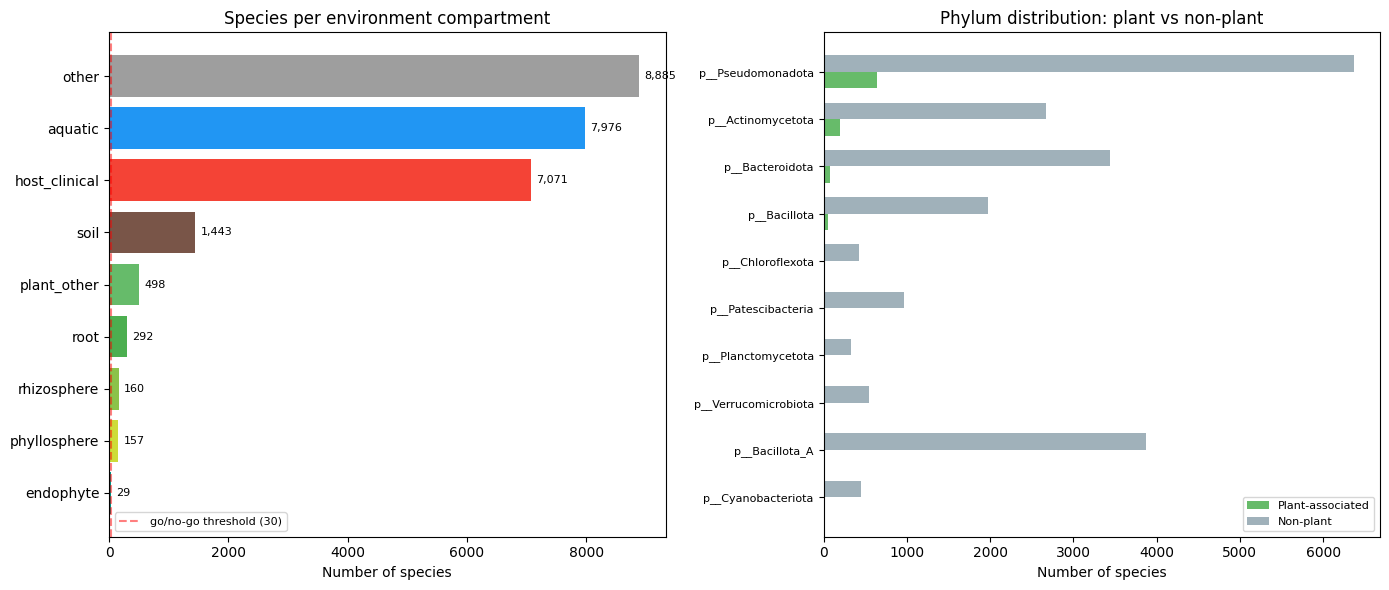

Saved figures/nb01_compartment_census.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: compartment species counts
ax = axes[0]
comp_order = compartment_census.sort_values('n_species', ascending=True)
colors_map = {
    'rhizosphere': '#8BC34A', 'root': '#4CAF50', 'phyllosphere': '#CDDC39',
    'endophyte': '#009688', 'plant_other': '#66BB6A',
    'soil': '#795548', 'host_clinical': '#F44336', 'aquatic': '#2196F3',
    'other': '#9E9E9E', 'unknown': '#BDBDBD'
}
bar_colors = [colors_map.get(c, '#9E9E9E') for c in comp_order['compartment']]
ax.barh(comp_order['compartment'], comp_order['n_species'], color=bar_colors)
ax.set_xlabel('Number of species')
ax.set_title('Species per environment compartment')
ax.axvline(30, color='red', linestyle='--', alpha=0.5, label='go/no-go threshold (30)')
ax.legend(fontsize=8)
for i, (_, row) in enumerate(comp_order.iterrows()):
    ax.text(row['n_species'] + comp_order['n_species'].max() * 0.01, i,
            f"{row['n_species']:,}", va='center', fontsize=8)

# Right: phylum distribution of plant-associated vs non-plant
ax = axes[1]
plant_sp = species_comp[species_comp['is_plant_associated'] == 1]
non_plant_sp = species_comp[species_comp['is_plant_associated'] == 0]
top_phyla = species_comp['phylum'].value_counts().head(10).index

plant_phyla = plant_sp[plant_sp['phylum'].isin(top_phyla)]['phylum'].value_counts()
non_plant_phyla = non_plant_sp[non_plant_sp['phylum'].isin(top_phyla)]['phylum'].value_counts()

phyla_df = pd.DataFrame({'plant': plant_phyla, 'non_plant': non_plant_phyla}).fillna(0)
phyla_df = phyla_df.sort_values('plant', ascending=True)

x = np.arange(len(phyla_df))
w = 0.35
ax.barh(x - w/2, phyla_df['plant'], w, label='Plant-associated', color='#4CAF50', alpha=0.85)
ax.barh(x + w/2, phyla_df['non_plant'], w, label='Non-plant', color='#90A4AE', alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(phyla_df.index, fontsize=8)
ax.set_xlabel('Number of species')
ax.set_title('Phylum distribution: plant vs non-plant')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'nb01_compartment_census.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/nb01_compartment_census.png')

## 8. Save outputs

In [11]:
# Save all outputs
env_df.to_csv(os.path.join(DATA, 'genome_environment.csv'), index=False)
species_comp.to_csv(os.path.join(DATA, 'species_compartment.csv'), index=False)
compartment_census.to_csv(os.path.join(DATA, 'compartment_census_summary.csv'), index=False)

print('=== NB01 Summary ===')
print(f'Total genomes processed: {len(env_df):,}')
print(f'Plant-associated genomes: {env_df["is_plant_associated"].sum():,}')
print(f'Species with compartment labels: {len(species_comp):,}')
print(f'Plant-associated species: {species_comp["is_plant_associated"].sum():,}')
print(f'H1 mode: {H1_MODE}')
print(f'\nOutputs saved to {DATA}/')
print('  - genome_environment.csv')
print('  - species_compartment.csv')
print('  - compartment_census_summary.csv')
print(f'\nReady for NB02 (marker gene survey)')

=== NB01 Summary ===
Total genomes processed: 293,059
Plant-associated genomes: 7,995
Species with compartment labels: 26,511
Plant-associated species: 1,136
H1 mode: plant_vs_nonplant

Outputs saved to /home/aparkin/BERIL-research-observatory/projects/plant_microbiome_ecotypes/data/
  - genome_environment.csv
  - species_compartment.csv
  - compartment_census_summary.csv

Ready for NB02 (marker gene survey)
